In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import re

In [2]:
import sqlite3
import glob
import os
import pandas as pd

db_files = sorted(glob.glob("/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nue_train/*65*.db"))
print(f"Found {len(db_files)} files")

rows = []
for f in db_files:
    try:
        con = sqlite3.connect(f)
        n_rows = con.execute("SELECT COUNT(*) FROM truth").fetchone()[0]
        n_distinct = con.execute("SELECT COUNT(DISTINCT event_no) FROM truth").fetchone()[0]
        con.close()
    except Exception as e:
        n_rows, n_distinct = None, None
        print(f"  FAILED: {f} -- {e}")
    rows.append({"file": os.path.basename(f), "n_rows": n_rows, "n_distinct_events": n_distinct})

df = pd.DataFrame(rows)
df["has_dupes"] = df["n_rows"] != df["n_distinct_events"]
df.to_csv("nue_train_65_event_counts.csv", index=False)

print(df[["n_rows", "n_distinct_events"]].describe())
print(f"\nTotal rows (all files): {df['n_rows'].sum()}")
print(f"Total distinct events (all files): {df['n_distinct_events'].sum()}")
print(f"Files with n_rows != n_distinct_events: {df['has_dupes'].sum()}")

KeyboardInterrupt: 

In [12]:
import sqlite3
import glob
import os
import pandas as pd

db_files = sorted(glob.glob("/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_train/*65*.db"))
print(f"Found {len(db_files)} files")

rows = []
for f in db_files:
    try:
        con = sqlite3.connect(f)
        n_rows = con.execute("SELECT COUNT(*) FROM truth").fetchone()[0]
        n_distinct = con.execute("SELECT COUNT(DISTINCT event_no) FROM truth").fetchone()[0]
        con.close()
    except Exception as e:
        n_rows, n_distinct = None, None
        print(f"  FAILED: {f} -- {e}")
    rows.append({"file": os.path.basename(f), "n_rows": n_rows, "n_distinct_events": n_distinct})

df = pd.DataFrame(rows)
df["has_dupes"] = df["n_rows"] != df["n_distinct_events"]
df.to_csv("nue_train_65_event_counts.csv", index=False)

print(df[["n_rows", "n_distinct_events"]].describe())
print(f"\nTotal rows (all files): {df['n_rows'].sum()}")
print(f"Total distinct events (all files): {df['n_distinct_events'].sum()}")
print(f"Files with n_rows != n_distinct_events: {df['has_dupes'].sum()}")

Found 556 files
           n_rows  n_distinct_events
count  556.000000         556.000000
mean    47.052158          47.052158
std     82.843557          82.843557
min      0.000000           0.000000
25%     13.000000          13.000000
50%     16.000000          16.000000
75%     20.000000          20.000000
max    568.000000         568.000000

Total rows (all files): 26161
Total distinct events (all files): 26161
Files with n_rows != n_distinct_events: 0


In [13]:
import sqlite3
import glob
import os
import pandas as pd

db_files = sorted(glob.glob("/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_test/*65*.db"))
print(f"Found {len(db_files)} files")

rows = []
for f in db_files:
    try:
        con = sqlite3.connect(f)
        n_rows = con.execute("SELECT COUNT(*) FROM truth").fetchone()[0]
        n_distinct = con.execute("SELECT COUNT(DISTINCT event_no) FROM truth").fetchone()[0]
        con.close()
    except Exception as e:
        n_rows, n_distinct = None, None
        print(f"  FAILED: {f} -- {e}")
    rows.append({"file": os.path.basename(f), "n_rows": n_rows, "n_distinct_events": n_distinct})

df = pd.DataFrame(rows)
df["has_dupes"] = df["n_rows"] != df["n_distinct_events"]
df.to_csv("nue_train_65_event_counts.csv", index=False)

print(df[["n_rows", "n_distinct_events"]].describe())
print(f"\nTotal rows (all files): {df['n_rows'].sum()}")
print(f"Total distinct events (all files): {df['n_distinct_events'].sum()}")
print(f"Files with n_rows != n_distinct_events: {df['has_dupes'].sum()}")

Found 556 files
           n_rows  n_distinct_events
count  556.000000         556.000000
mean    51.633094          51.633094
std     68.899629          68.899629
min      1.000000           1.000000
25%     23.750000          23.750000
50%     27.000000          27.000000
75%     33.000000          33.000000
max    473.000000         473.000000

Total rows (all files): 28708
Total distinct events (all files): 28708
Files with n_rows != n_distinct_events: 0


In [2]:
# logfile = '/mnt/scratch/baburish/doublepulse/gnn/Analysis/logs/22644slurm_GAT.log'
logfile = '/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss2p0/c.log'
logfile = '/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p5dropout/a.log'
logfile = '/mnt/scratch/baburish/doublepulse/gnn/Analysis/c1.log'
with open(logfile, 'r') as f:
    lines = f.readlines()

In [3]:
#Epoch   3 | Train: 0.7505 | Val: 0.7251 | AUC: 0.7451 | Best: 0.7451
total_epochs = 110
epochs = []
train_loss = []
val_loss = []
auc = []
pattern = r"Epoch\s+(\d+)\s+\|\s+Train:\s+([\d\.]+)\s+\|\s+Val:\s+([\d\.]+)\s+\|\s+AUC:\s+([\d\.]+)\s+\|\s+Best:\s+([\d\.]+)"
for line in lines:
    match = re.search(pattern, line)
    if match:
        epochs.append(int(match.group(1)))
        train_loss.append(float(match.group(2)))
        val_loss.append(float(match.group(3)))
        auc.append(float(match.group(4)))

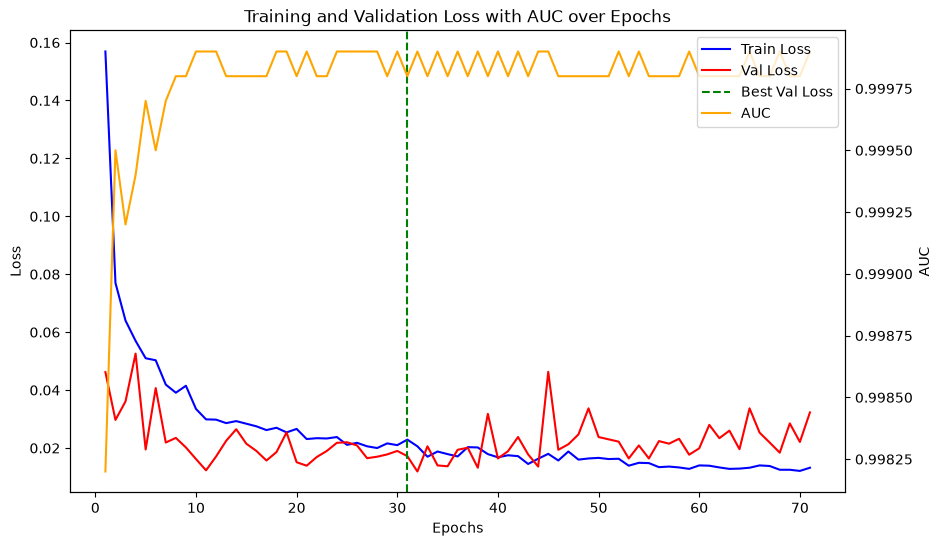

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epochs, train_loss, label='Train Loss', color='blue')
ax.plot(epochs, val_loss, label='Val Loss', color='red')
ax.axvline(val_loss.index(min(val_loss)), color='green', linestyle='--', label='Best Val Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax2 = ax.twinx()
ax2.plot(epochs, auc, label='AUC', color='orange')
ax2.set_ylabel('AUC')
ax.set_title('Training and Validation Loss with AUC over Epochs')
# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')
plt.show()

In [5]:
for i, j, k, l in zip(epochs, train_loss, val_loss, auc):
    print(f"Epoch: {i}, Train Loss: {j}, Val Loss: {k}, AUC: {l}")

Epoch: 1, Train Loss: 0.1569, Val Loss: 0.0462, AUC: 0.9982
Epoch: 2, Train Loss: 0.077, Val Loss: 0.0297, AUC: 0.9995
Epoch: 3, Train Loss: 0.064, Val Loss: 0.0361, AUC: 0.9992
Epoch: 4, Train Loss: 0.057, Val Loss: 0.0526, AUC: 0.9994
Epoch: 5, Train Loss: 0.051, Val Loss: 0.0195, AUC: 0.9997
Epoch: 6, Train Loss: 0.0503, Val Loss: 0.0407, AUC: 0.9995
Epoch: 7, Train Loss: 0.0419, Val Loss: 0.0219, AUC: 0.9997
Epoch: 8, Train Loss: 0.0391, Val Loss: 0.0235, AUC: 0.9998
Epoch: 9, Train Loss: 0.0415, Val Loss: 0.0202, AUC: 0.9998
Epoch: 10, Train Loss: 0.0335, Val Loss: 0.0162, AUC: 0.9999
Epoch: 11, Train Loss: 0.0299, Val Loss: 0.0123, AUC: 0.9999
Epoch: 12, Train Loss: 0.0298, Val Loss: 0.0171, AUC: 0.9999
Epoch: 13, Train Loss: 0.0286, Val Loss: 0.0225, AUC: 0.9998
Epoch: 14, Train Loss: 0.0293, Val Loss: 0.0265, AUC: 0.9998
Epoch: 15, Train Loss: 0.0284, Val Loss: 0.0215, AUC: 0.9998
Epoch: 16, Train Loss: 0.0275, Val Loss: 0.019, AUC: 0.9998
Epoch: 17, Train Loss: 0.0262, Val Los

In [10]:
max(auc)

0.7553

Epoch: 34, Train Loss: 0.6434, Val Loss: 0.681, AUC: 0.7888
Epoch: 35, Train Loss: 0.6415, Val Loss: 0.6763, AUC: 0.7878
Epoch: 36, Train Loss: 0.6402, Val Loss: 0.6776, AUC: 0.7882
Epoch: 37, Train Loss: 0.6407, Val Loss: 0.6754, AUC: 0.7931
Epoch: 38, Train Loss: 0.6367, Val Loss: 0.6885, AUC: 0.7875
Epoch: 39, Train Loss: 0.6369, Val Loss: 0.692, AUC: 0.7831
Epoch: 40, Train Loss: 0.6338, Val Loss: 0.678, AUC: 0.7896
Epoch: 41, Train Loss: 0.6323, Val Loss: 0.6913, AUC: 0.7874
Epoch: 42, Train Loss: 0.6302, Val Loss: 0.6896, AUC: 0.7885
Epoch: 43, Train Loss: 0.6315, Val Loss: 0.6898, AUC: 0.7868
Epoch: 44, Train Loss: 0.6284, Val Loss: 0.6917, AUC: 0.7887
Epoch: 45, Train Loss: 0.6276, Val Loss: 0.6897, AUC: 0.7878
Epoch: 46, Train Loss: 0.627, Val Loss: 0.6872, AUC: 0.7892
Epoch: 47, Train Loss: 0.6247, Val Loss: 0.6951, AUC: 0.7875

python infer.py --model_path /mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss3p0/hybrid_weights.pt --scaler_path /mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss3p0/pca_scaler.joblib --nue_dbs /mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nue_test/*65TeV* --tau_dbs /mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_test/*65TeV* --geo data/geometry_clean.csv --save_dir trained_model/infer_GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss3p --max_events 10000

python infer.py --model_path /mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss2p0/hybrid_weights.pt --scaler_path /mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss2p0/pca_scaler.joblib --nue_dbs /mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nue_test/*65TeV* --tau_dbs /mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_test/*65TeV* --geo data/geometry_clean.csv --save_dir trained_model/infer_GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss2p --max_events 10000